500 500


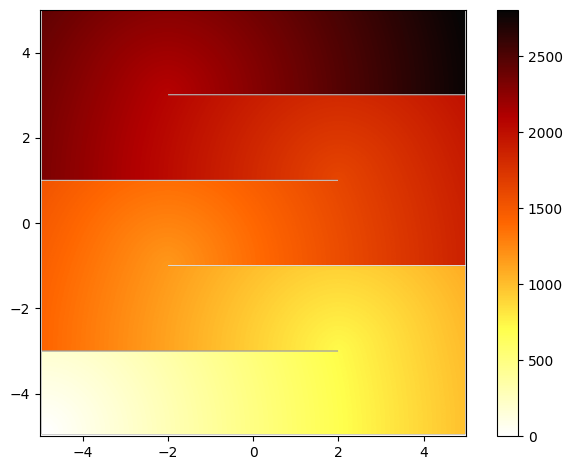

In [ ]:
# ==============================================================================
# ----------------- VERSIONE MIA SU LABIRINTO 500X500 --------------------------
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx = 500
ny = 500
sidex = 5
sidey = 5
nRows =500
nCols =500
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)

ix0 = 5
iy0 = 5

#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 0.01 * np.ones(X.shape)

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 0.01

# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 0.01

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 0.01

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 0.01


# ==============================================================================
# CALCOLO ICONALE
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0


active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

nRows, nCols = T.shape
converged = np.zeros(T.shape, dtype=bool)
active = np.zeros(T.shape, dtype=bool)
T_old = np.full(T.shape, np.inf)
continua = True
h = dx

print(nRows, nCols)

#------------------  AGGIORNAMENTO ICONALE + GODUNOV 1 -------------------------

while continua:
    row, col = np.where(np.isfinite(T))
    active[row, col] = True

    while np.any(active):
        row, col = np.where(active)
        num = len(row)

        for i in range(num):
            # calcolo sullo stencil
            for k in range(num):
                converged[row[k], col[k]] = True
                active[row[k], col[k]] = False

            # aggiorno dx
            if (col[i] + 2 < nCols) and not converged[row[i], col[i] + 1]:
                if not np.isinf(F[row[i], col[i] + 1]):
                    Tx = min(T[row[i], col[i]], T[row[i], col[i] + 2])
                    Ty = min(T[row[i] + 1, col[i] + 1], T[row[i] - 1, col[i] + 1])
                    a = min(Tx, Ty)
                    b = max(Tx, Ty)
                    if (b - a) < h / F[row[i], col[i] + 1]:
                        T_new = (a + b + np.sqrt(2 * (h / F[row[i], col[i] + 1])**2 - (a - b)**2)) / 2
                    else:
                        T_new = a + h / F[row[i], col[i] + 1]
                    if T_new < T[row[i], col[i] + 1]:
                        T[row[i], col[i] + 1] = T_new
                    active[row[i], col[i] + 1] = True

            # aggiorno sx
            if (col[i] - 2 > 0) and not converged[row[i], col[i] - 1]:
                if not np.isinf(F[row[i], col[i] - 1]):
                    Tx = min(T[row[i], col[i]], T[row[i], col[i] - 2])
                    Ty = min(T[row[i] + 1, col[i] - 1], T[row[i] - 1, col[i] - 1])
                    a = min(Tx, Ty)
                    b = max(Tx, Ty)
                    if (b - a) < h / F[row[i], col[i] - 1]:
                        T_new = (a + b + np.sqrt(2 * (h / F[row[i], col[i] - 1])**2 - (a - b)**2)) / 2
                    else:
                        T_new = a + h / F[row[i], col[i] - 1]
                    if T_new < T[row[i], col[i] - 1]:
                        T[row[i], col[i] - 1] = T_new
                    active[row[i], col[i] - 1] = True

            # aggiorno giù
            if (row[i] + 2 < nRows) and not converged[row[i] + 1, col[i]]:
                if not np.isinf(F[row[i] + 1, col[i]]):
                    Tx = min(T[row[i], col[i]], T[row[i] + 2, col[i]])
                    Ty = min(T[row[i] + 1, col[i] - 1], T[row[i] + 1, col[i] + 1])
                    a = min(Tx, Ty)
                    b = max(Tx, Ty)
                    if (b - a) < h / F[row[i] + 1, col[i]]:
                        T_new = (a + b + np.sqrt(2 * (h / F[row[i] + 1, col[i]])**2 - (a - b)**2)) / 2
                    else:
                        T_new = a + h / F[row[i] + 1, col[i]]
                    if T_new < T[row[i] + 1, col[i]]:
                        T[row[i] + 1, col[i]] = T_new
                    active[row[i] + 1, col[i]] = True

            # aggiorno su
            if (row[i] - 2 > 0) and not converged[row[i] - 1, col[i]]:
                if not np.isinf(F[row[i] - 1, col[i]]):
                    Tx = min(T[row[i], col[i]], T[row[i] - 2, col[i]])
                    Ty = min(T[row[i] - 1, col[i] - 1], T[row[i] - 1, col[i] + 1])
                    a = min(Tx, Ty)
                    b = max(Tx, Ty)
                    if (b - a) < h / F[row[i] - 1, col[i]]:
                        T_new = (a + b + np.sqrt(2 * (h / F[row[i] - 1, col[i]])**2 - (a - b)**2)) / 2
                    else:
                        T_new = a + h / F[row[i] - 1, col[i]]
                    if T_new < T[row[i] - 1, col[i]]:
                        T[row[i] - 1, col[i]] = T_new
                    active[row[i] - 1, col[i]] = True

    if np.array_equal(T_old, T):
        continua = True  # nessun cambiamento: esci
    else:
        continua = False   # ripeti un'altra iterazione

    T_old = T.copy()

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

# Colormap personalizzata
stops = np.array([
    [1.00, 1.00, 1.00],  # bianco (bassi)
    [1.00, 1.00, 0.30],  # giallo chiaro
    [1.00, 0.40, 0.00],  # arancio
    [0.70, 0.00, 0.00],  # rosso scuro
    [0.02, 0.02, 0.02],  # quasi nero (alti)
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()

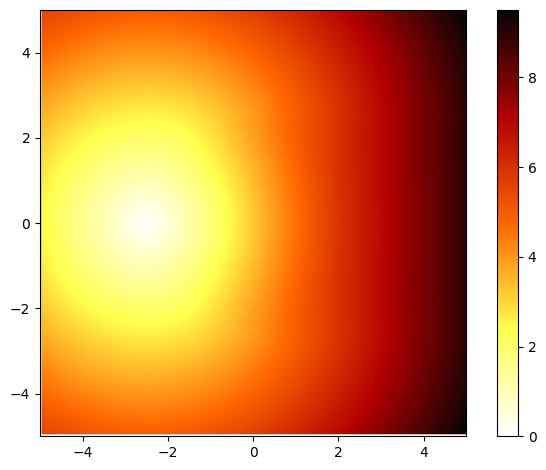

In [2]:
# ==============================================================================
# ----------------- VERSIONE MIA SU LENTE DI LUNEBURG --------------------------
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt
from matplotlib.patches import Circle

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx = 500
ny = 500
sidex = 5
sidey = 5
nRows =500
nCols =500
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)

#------------------  CAMPO DI VELOCITA' (LENTE DI LUNEBURG) --------------------

F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), np.ones(X.shape).T,
                                    method='linear', bounds_error=False, fill_value=None)

# --- parametri della lente ---
R_lens = 2.5        # raggio della lente di Luneburg
xc, yc = 0.0, 0.0   # centro della lente (nell'origine del dominio)
rho = np.sqrt((X - xc)**2 + (Y - yc)**2)
inside = rho < R_lens

n_luneburg = np.ones(X.shape)
n_luneburg[inside] = np.sqrt(2.0 - (rho[inside] / R_lens)**2)

F = np.ones(X.shape)
F = 1.0 / n_luneburg   # F è la VELOCITA', reciproca dell'indice di rifrazione
F[inside] = 1.0 / np.sqrt(2.0 - (rho[inside] / R_lens)**2)

wall_mask = np.isinf(F)

# ==============================================================================
# CALCOLO ICONALE
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

ix0 = np.argmin(np.abs(x - (xc - R_lens)))   # colonna corrispondente a x = xc - R_lens
iy0 = np.argmin(np.abs(y - yc))              # riga corrispondente a y = yc

source_pt = (x[ix0], y[iy0])   # coordinate fisiche della sorgente (il fuoco della lente)

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0


active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

nRows, nCols = T.shape
converged = np.zeros(T.shape, dtype=bool)
active = np.zeros(T.shape, dtype=bool)
T_old = np.full(T.shape, np.inf)
continua = True
h = dx


#------------------  AGGIORNAMENTO ICONALE + GODUNOV 1 -------------------------

while continua:
    row, col = np.where(np.isfinite(T))
    active[row, col] = True

    while np.any(active):
        row, col = np.where(active)
        num = len(row)

        for i in range(num):
            # calcolo sullo stencil
            for k in range(num):
                converged[row[k], col[k]] = True
                active[row[k], col[k]] = False

            # aggiorno dx
            if (col[i] + 2 < nCols) and not converged[row[i], col[i] + 1]:
                if not np.isinf(F[row[i], col[i] + 1]):
                    Tx = min(T[row[i], col[i]], T[row[i], col[i] + 2])
                    Ty = min(T[row[i] + 1, col[i] + 1], T[row[i] - 1, col[i] + 1])
                    a = min(Tx, Ty)
                    b = max(Tx, Ty)
                    if (b - a) < h / F[row[i], col[i] + 1]:
                        T_new = (a + b + np.sqrt(2 * (h / F[row[i], col[i] + 1])**2 - (a - b)**2)) / 2
                    else:
                        T_new = a + h / F[row[i], col[i] + 1]
                    if T_new < T[row[i], col[i] + 1]:
                        T[row[i], col[i] + 1] = T_new
                    active[row[i], col[i] + 1] = True

            # aggiorno sx
            if (col[i] - 2 > 0) and not converged[row[i], col[i] - 1]:
                if not np.isinf(F[row[i], col[i] - 1]):
                    Tx = min(T[row[i], col[i]], T[row[i], col[i] - 2])
                    Ty = min(T[row[i] + 1, col[i] - 1], T[row[i] - 1, col[i] - 1])
                    a = min(Tx, Ty)
                    b = max(Tx, Ty)
                    if (b - a) < h / F[row[i], col[i] - 1]:
                        T_new = (a + b + np.sqrt(2 * (h / F[row[i], col[i] - 1])**2 - (a - b)**2)) / 2
                    else:
                        T_new = a + h / F[row[i], col[i] - 1]
                    if T_new < T[row[i], col[i] - 1]:
                        T[row[i], col[i] - 1] = T_new
                    active[row[i], col[i] - 1] = True

            # aggiorno giù
            if (row[i] + 2 < nRows) and not converged[row[i] + 1, col[i]]:
                if not np.isinf(F[row[i] + 1, col[i]]):
                    Tx = min(T[row[i], col[i]], T[row[i] + 2, col[i]])
                    Ty = min(T[row[i] + 1, col[i] - 1], T[row[i] + 1, col[i] + 1])
                    a = min(Tx, Ty)
                    b = max(Tx, Ty)
                    if (b - a) < h / F[row[i] + 1, col[i]]:
                        T_new = (a + b + np.sqrt(2 * (h / F[row[i] + 1, col[i]])**2 - (a - b)**2)) / 2
                    else:
                        T_new = a + h / F[row[i] + 1, col[i]]
                    if T_new < T[row[i] + 1, col[i]]:
                        T[row[i] + 1, col[i]] = T_new
                    active[row[i] + 1, col[i]] = True

            # aggiorno su
            if (row[i] - 2 > 0) and not converged[row[i] - 1, col[i]]:
                if not np.isinf(F[row[i] - 1, col[i]]):
                    Tx = min(T[row[i], col[i]], T[row[i] - 2, col[i]])
                    Ty = min(T[row[i] - 1, col[i] - 1], T[row[i] - 1, col[i] + 1])
                    a = min(Tx, Ty)
                    b = max(Tx, Ty)
                    if (b - a) < h / F[row[i] - 1, col[i]]:
                        T_new = (a + b + np.sqrt(2 * (h / F[row[i] - 1, col[i]])**2 - (a - b)**2)) / 2
                    else:
                        T_new = a + h / F[row[i] - 1, col[i]]
                    if T_new < T[row[i] - 1, col[i]]:
                        T[row[i] - 1, col[i]] = T_new
                    active[row[i] - 1, col[i]] = True

    if np.array_equal(T_old, T):
        continua = True  # nessun cambiamento: esci
    else:
        continua = False   # ripeti un'altra iterazione

    T_old = T.copy()

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

# Colormap personalizzata
stops = np.array([
    [1.00, 1.00, 1.00],  # bianco (bassi)
    [1.00, 1.00, 0.30],  # giallo chiaro
    [1.00, 0.40, 0.00],  # arancio
    [0.70, 0.00, 0.00],  # rosso scuro
    [0.02, 0.02, 0.02],  # quasi nero (alti)
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()

T_final = T.copy()
